In [91]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [ ]:
def Beers_law(power_input,attenuation,distance): #Power at distance due to attenuation

    power_out = power_input*np.exp(-attenuation*distance)

    return power_out


def Mie_scattering_naive(V,wavelength):
    """Scattering due to aerosols (wavelength and particle size on the same order). 
    Naive, empirical model (Kruse model) since we extrapolate from data taken at 550nm, which breaks down at around 1600nm.
    
    V: Visibility [km]. The distance at which the human eye can not distinguish the contrast of a black object in the sky. The eye works best at 550nm.
    Formally, when C(V)=(L_o(V)-L_b)/L_b =0.02. When the luminance of the object falls to 2% compared to the background. 
    Set equal to exp(-beta_ext * V), where beta_ext is the attenuation, you obtain beta_ext = ln(0.02)/V = 3.91/V.

    q: The size distribution of the scattering particles. 
    It is assumed that when visibility drops, it is also due to the formation of larger particles and not only due to an increase in number of particles per volume.
    Larger particles care less about wavelength. Fits well, with haze, fog, etc., that the particles grow in size and numbers.
    V > 50km: q = 1.6. Clean air.
    6km < V < 50km: q = 1.3. The medium visibility, haze, fits under hygroscopic growth, molecules retain water from humid air.
    V < 6km: q = 0.585*V**(1/3). Low visibility, fog, liquid water drops are formed.

    The extrapolation breaks down at wavelengths around 1600nm, due to a distribution peak of the aerosols around 1-3µm. 
    These will matter less for larger wavelengths, and on a log-log plot, the scattering contribution will go from a downwards linear trends to a flat line when wavelength increases.
    When looking at where Mie-scattering is relevant, we see that when the particle size incresases, the number density reduces. 
    However, the scattering also depends on the size of the particle. The result is a flat line on a log-log scale.

    Output: attenuation coefficent in 
    """
    
    wave_ref = 550*1e-9 #reference wavelength 550nm, optimal eye performance

    if V < 6: #km
        q=0.585 * V**(1/3)
    elif (V >= 6) and (V < 50):
        q=1.3

    else:
        q=1.6


    att_Mie = -np.log(0.02)/V * (wavelength/wave_ref)**(-q)

    return att_Mie


def Mie_and_geo_scattering_mix(V,wavelength,att_geo,lambda_c=1600*1e-9):
    """Mix of Mie and geometric scattering.
    
    att_geo: [1/km], not in dB Attenuation due to geometric scattering. Essentially a floor for the attenuation, since it is independent of wavelength.
    lambda_c: [m], cutoff wavelength for the transition between Mie and geometric scattering.

    Returns: Combined attenuation coefficient.
    """
    wave_ref = 550*1e-9 #reference wavelength 550nm, optimal eye performance

    if V < 6: #km
        q=0.585 * V**(1/3)
    elif (V >= 6) and (V < 50):
        q=1.3

    else:
        q=1.6

    att_Mie = -np.log(0.02)/V * (wavelength/wave_ref)**(-q)


    x = (wavelength / lambda_c)**q
    
    mix = (att_Mie + att_geo * x) / (1 + x)


    return mix





def Rayleigh_scattering(N_p, A_p, wavelength): 
    """Attenaution due to scattering on molecules (wavelength much larger than molecule/particle size). 
    Negligible for IR (+800nm).
    N_p: particle number per unit volume. 
    A_p: Cross-sectional area of scattering.
    
    Returns: attenuation coefficient dependent on wavelength"""

    att_Rayleigh = 0.827 * N_p * A_p**3 * wavelength**(-4)

    return att_Rayleigh


def Rayleigh_scattering(N_p, A_p, wavelength): 
    """Attenaution due to scattering on molecules (wavelength much larger than molecule/particle size). 
    Negligible for IR (+800nm).
    N_p: particle number per unit volume
    A_p: Cross-sectional area of scattering
    
    Returns: attenuation coefficient dependent on wavelength"""

    att_Rayleigh = 0.827 * N_p * A_p**3 * wavelength**(-4)

    return att_Rayleigh



In [93]:
-np.log(0.02)

np.float64(3.912023005428146)

In [94]:
# We use the empirical "naive" Mie scattering model to calculate attenuation coefficients based on visibility and wavelength.

# wavelengths = np.array([850,1550])*1e-9 #m Trichili paper
# vis = np.array([23,4,2,1,0.5,0.2,0.05]) #km Trichili paper

wavelengths = np.array([1550,4000,9000])*1e-9 #m Grillot paper
vis = np.array([20,5,2,1]) #km Grillot paper

wavelength_labels = [f"{int(wav*1e9)} nm" for wav in wavelengths]


attenuation_dB = np.zeros((len(vis), len(wavelengths)))
lin_to_dB_coef = 10 * np.log10(np.exp(1))

for i, V in enumerate(vis):
    for j, wav in enumerate(wavelengths):
        attenuation = Mie_scattering_naive(V, wav)
        attenuation_dB[i, j] = lin_to_dB_coef * attenuation

wavelength_labels = [f"{int(wav*1e9)} nm" for wav in wavelengths]
attenuation_df = pd.DataFrame(attenuation_dB, index=vis, columns=wavelength_labels)
attenuation_df.index.name = "Vis [km]"
attenuation_dict = attenuation_df.to_dict(orient="index")

print(attenuation_df)


           1550 nm   4000 nm   9000 nm
Vis [km]                              
20        0.220900  0.064409  0.022445
5         1.205301  0.466905  0.207457
2         3.958260  1.968060  1.082582
1         9.267313  5.322220  3.311815


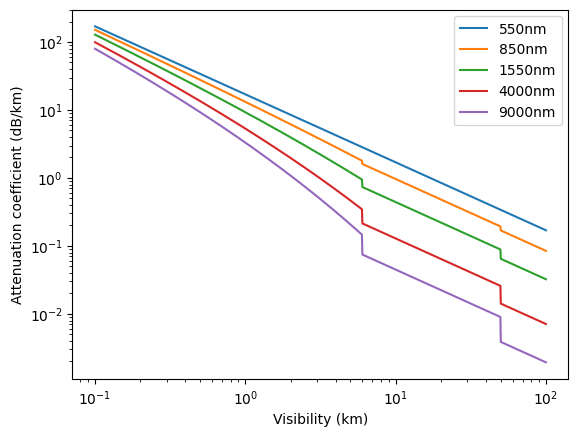

In [95]:
#Plotting naive Mie model attenuation coefficients vs visibility for different wavelengths
visibility = np.logspace(-1,2,1001) #km

Mie_att_550 = [lin_to_dB_coef*Mie_scattering_naive(V, 550e-9) for V in visibility]
Mie_att_850 = [lin_to_dB_coef*Mie_scattering_naive(V, 850e-9) for V in visibility]
Mie_att_1550 = [lin_to_dB_coef*Mie_scattering_naive(V, 1550e-9) for V in visibility]
Mie_att_4000 = [lin_to_dB_coef*Mie_scattering_naive(V, 4000e-9) for V in visibility]
Mie_att_9000 = [lin_to_dB_coef*Mie_scattering_naive(V, 9000e-9) for V in visibility]



plt.plot(visibility, Mie_att_550, label='550nm')
plt.plot(visibility, Mie_att_850, label='850nm')
plt.plot(visibility, Mie_att_1550, label='1550nm')
plt.plot(visibility, Mie_att_4000, label='4000nm')
plt.plot(visibility, Mie_att_9000, label='9000nm')
plt.xlabel('Visibility (km)')
plt.ylabel('Attenuation coefficient (dB/km)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

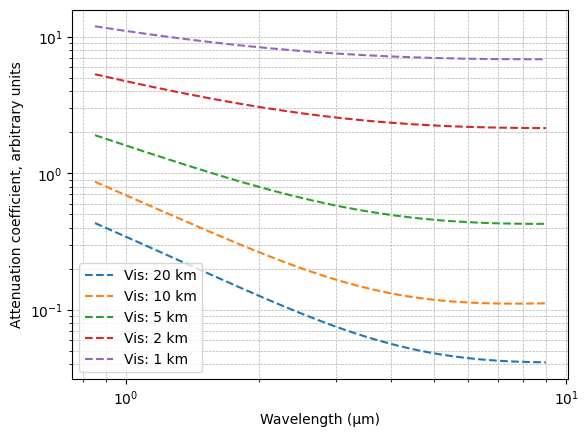

In [109]:
# We use the empirical "naive" Mie scattering model to calculate attenuation coefficients based on visibility and wavelength.
#Model testing, since the model doesn't work outside 1.6µm, due to the distribution of aerosols around 1-3µm.

wavelengths = np.linspace(850, 9000, 1000)*1e-9 #m
vis = np.array([20,10,5,2,1]) #km 

wavelength_labels = [f"{int(wav*1e9)} nm" for wav in wavelengths]

lin_to_dB_coef = 10 * np.log10(np.exp(1))
front_factors = np.array([Mie_scattering_naive(V, 1600e-9)/V**0.5 for V in vis])

attenuation_dB = np.zeros((len(vis), len(wavelengths)))
attenuation_dB_mix = attenuation_dB.copy()
plt.figure() 
for i, V in enumerate(vis):
    for j, wav in enumerate(wavelengths):
        attenuation = Mie_scattering_naive(V, wav)
        attenuation_mix = Mie_and_geo_scattering_mix(V, wav, att_geo=front_factors[i], lambda_c=4e-6)

        attenuation_dB[i, j] = lin_to_dB_coef * attenuation
        attenuation_dB_mix[i, j] = lin_to_dB_coef * attenuation_mix
    
    # line, = plt.plot(wavelengths*1e6, attenuation_dB[i], label=f'Vis: {V} km')
    plt.plot(wavelengths*1e6, attenuation_dB_mix[i], '--',label=f'Vis: {V} km')


plt.xlabel('Wavelength (µm)')
plt.ylabel('Attenuation coefficient, arbitrary units')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)

C:\Users\au617810\AppData\Local\Temp\ipykernel_19696\3498318853.py:22: RuntimeWarning: divide by zero encountered in log10
  ax.plot(distance, 10*np.log10(Beers_law(1, attenuation, distance)), label=f"{(wav*1e6):.2f}µm")


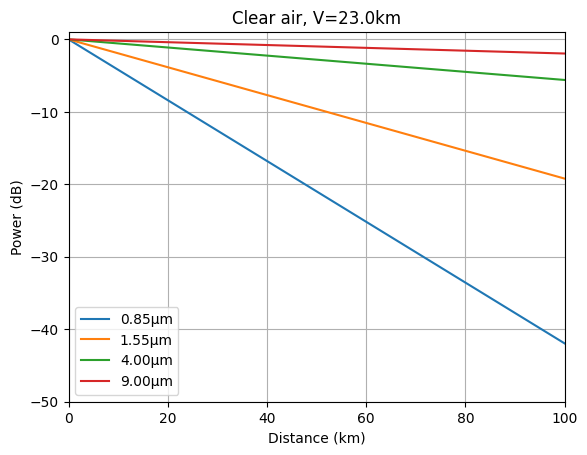

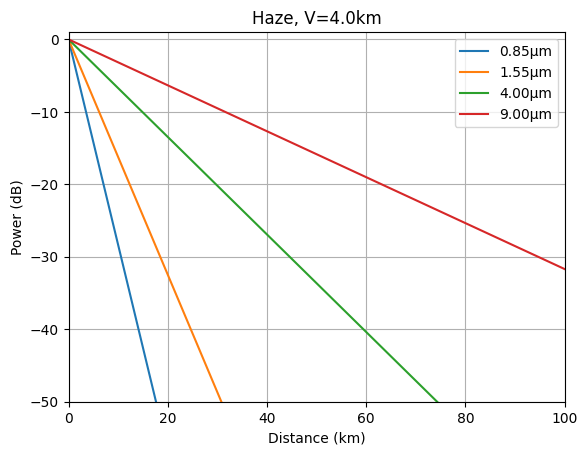

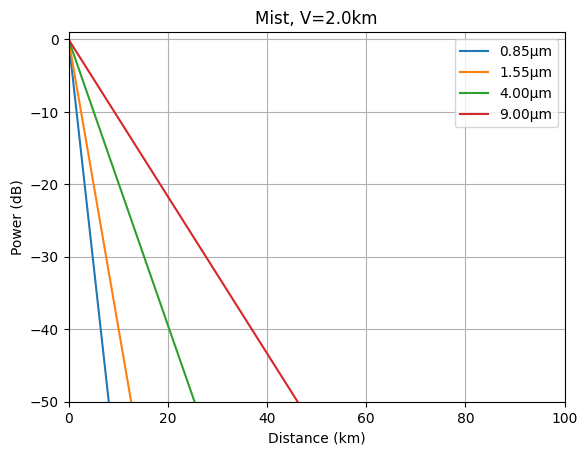

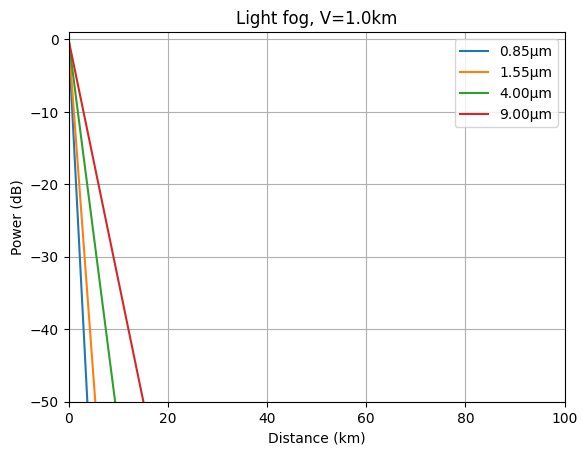

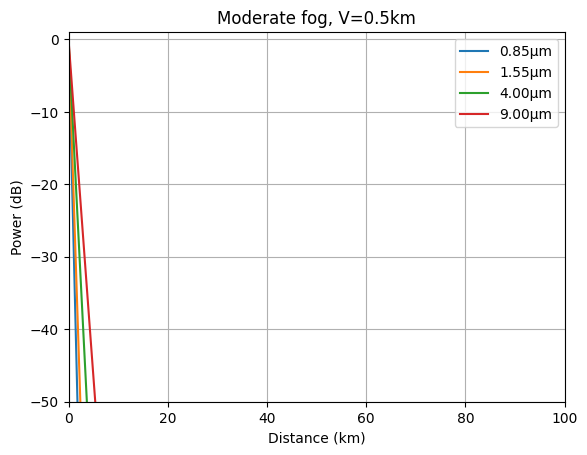

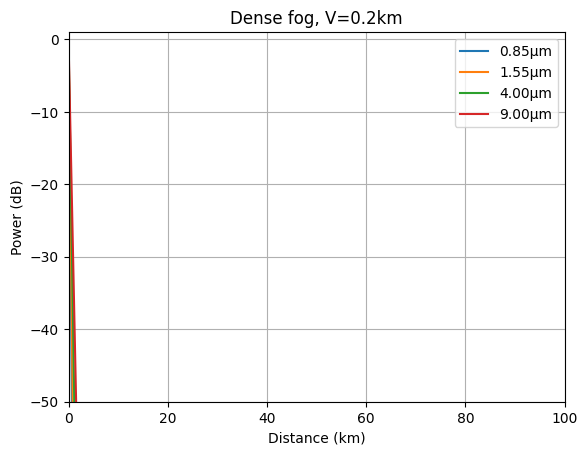

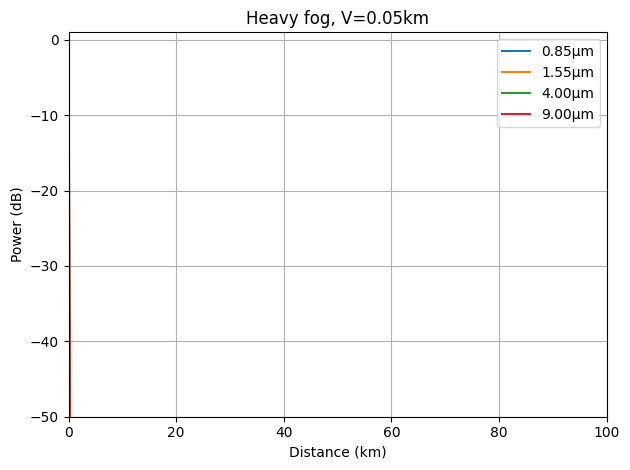

In [ ]:
# We assume negligible Rayleigh scattering and absorption for FSO chosen at 0.850, 1.55, 4, 9µm.
# We then calculate the power attenuation in dB for various visibiliities dependent on transmitted distance, using Beer's law.

distance = np.logspace(-2,2, 1001) #km

wavelengths = np.array([850,1550,4000,9000])*1e-9 #m Grillot paper
vis = np.array([23,4,2,1,0.5,0.2,0.05]) #km Trichili paper

atmospheric_conditions = ['Clear air', 'Haze', 'Mist', 'Light fog', 'Moderate fog', 'Dense fog', 'Heavy fog']

# fig, axes = plt.subplots(4, 2, figsize=(14, 12))
# axes = axes.flatten()

for i, V in enumerate(vis):
    # ax = axes[i]
    
    fig = plt.figure()
    ax = fig.add_subplot(111)

    
    ax.set_title(f"{atmospheric_conditions[i]}, V={V}km")
    for j, wav in enumerate(wavelengths):
        attenuation = Mie_scattering_naive(V, wav)
        ax.plot(distance, 10*np.log10(Beers_law(1, attenuation, distance)), label=f"{(wav*1e6):.2f}µm")
    ax.set_xlabel('Distance (km)')
    ax.set_ylabel('Power (dB)')
    ax.legend()
    ax.grid('ON')
    ax.set_ylim(-50, 1)
    ax.set_xlim(0, 100)
    # ax.set_xscale('log')

axes[7].axis('off')
plt.tight_layout()
  





In [ ]:
# We use the empirical "naive" Mie scattering model to calculate attenuation coefficients based on visibility and wavelength.

# wavelengths = np.array([850,1550])*1e-9 #m Trichili paper
# vis = np.array([23,4,2,1,0.5,0.2,0.05]) #km Trichili paper

wavelengths = np.array([1550,4000,9000])*1e-9 #m Grillot paper
vis = np.array([20,5,2,1]) #km Grillot paper

wavelength_labels = [f"{int(wav*1e9)} nm" for wav in wavelengths]


attenuation_dB = np.zeros((len(vis), len(wavelengths)))
lin_to_dB_coef = 10 * np.log10(np.exp(1))

for i, V in enumerate(vis):
    for j, wav in enumerate(wavelengths):
        attenuation = Mie_scattering_naive(V, wav)
        attenuation_dB[i, j] = lin_to_dB_coef * attenuation

wavelength_labels = [f"{int(wav*1e9)} nm" for wav in wavelengths]
attenuation_df = pd.DataFrame(attenuation_dB, index=vis, columns=wavelength_labels)
attenuation_df.index.name = "Vis [km]"
attenuation_dict = attenuation_df.to_dict(orient="index")

print(attenuation_df)


           1550 nm   4000 nm   9000 nm
Vis [km]                              
20        0.220900  0.064409  0.022445
5         1.205301  0.466905  0.207457
2         3.958260  1.968060  1.082582
1         9.267313  5.322220  3.311815
